> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 22. Imbalanced Data and Data Leakage

*Scope:* Two causes of a score that is better than the model - the wrong metric, and information the model will not have at prediction time - each reproduced with its inflated number, then repaired.

Two subjects, one chapter, because they produce the same symptom: **a score that is far better than the
model is**.

Imbalance inflates the score because the metric was the wrong one. Leakage inflates it because the model
saw something it will not have at prediction time. In both cases the number on the slide is real
arithmetic on real data, and in both cases it will not survive deployment — which is what makes them
harder to catch than a bug.

Every failure in this chapter is reproduced with its inflated number printed, then repaired.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold,
                                     GroupKFold, TimeSeriesSplit, cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             average_precision_score, f1_score, recall_score,
                             precision_score, confusion_matrix, matthews_corrcoef,
                             precision_recall_curve, classification_report)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80
print("ready")

ready


### 22.1 Where Imbalance Comes From

Class imbalance is not a defect in the data. It is usually the data being honest about a world in which
the interesting thing is rare.

| Source | Example | Ratio typically |
|---|---|---|
| **The event really is rare** | Fraud, equipment failure, rare disease | 1:100 – 1:100,000 |
| **Collection is asymmetric** | Only complaints get logged | Unknown and unknowable |
| **The window is too short** | Annual churn measured over one month | Artificially rare |
| **The label is a proxy** | "Clicked" as a stand-in for "interested" | Varies |

That distinction matters because the *fix* differs. Only the first row is genuine imbalance to be modelled;
the third is a labelling mistake to be corrected upstream, and resampling it would entrench the error.

**The ratio decides how much trouble you are in**, but so does the absolute count. 100 positives out of
1,000 is a different problem from 100 out of 1,000,000 — the same 10 : 1 versus 10,000 : 1 ratio hides the
fact that both have only 100 examples to learn the positive class from.

In [2]:
def imbalanced_data(n=5000, weight=0.99, seed=RANDOM_STATE, n_informative=5):
    X, y = make_classification(n_samples=n, n_features=12, n_informative=n_informative,
                               n_redundant=2, weights=[weight, 1 - weight],
                               flip_y=0.01, class_sep=0.8, random_state=seed)
    return X, y


X_imb, y_imb = imbalanced_data(weight=0.97)
print(f"{len(y_imb)} rows, {y_imb.sum()} positives ({y_imb.mean():.2%})")
print(f"imbalance ratio: 1 : {int((1 - y_imb.mean()) / y_imb.mean())}")

5000 rows, 164 positives (3.28%)
imbalance ratio: 1 : 29


In [3]:
# The two quantities that matter are not the same thing.
print(f"{'rows':>10}{'rate':>9}{'positives':>12}{'harder because':>28}")
for n, rate in ((1_000, 0.10), (1_000_000, 0.0001), (200, 0.25)):
    pos = int(n * rate)
    reason = "few positives" if pos < 60 else "extreme ratio" if rate < 0.001 else "-"
    print(f"{n:>10,}{rate:>9.2%}{pos:>12,}{reason:>28}")

      rows     rate   positives              harder because
     1,000   10.00%         100                           -
 1,000,000    0.01%         100               extreme ratio
       200   25.00%          50               few positives


### 22.2 Why Accuracy Lies

With 3% positives, a model that predicts "negative" for every row is 97% accurate. This is not a subtle
point, but it survives in dashboards because 97% reads as success.

8.5 covered the metrics; here is what each one does to the constant model, which is the only baseline that
matters under imbalance.

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3,
                                          stratify=y_imb, random_state=RANDOM_STATE)

dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
model = Pipeline([("scale", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=1000,
                                             random_state=RANDOM_STATE))]).fit(X_tr, y_tr)

def report(name, est):
    pred = est.predict(X_te)
    proba = est.predict_proba(X_te)[:, 1]
    return {"accuracy": accuracy_score(y_te, pred),
            "balanced acc": balanced_accuracy_score(y_te, pred),
            "precision": precision_score(y_te, pred, zero_division=0),
            "recall": recall_score(y_te, pred, zero_division=0),
            "F1": f1_score(y_te, pred, zero_division=0),
            "MCC": matthews_corrcoef(y_te, pred),
            "ROC-AUC": roc_auc_score(y_te, proba),
            "PR-AUC": average_precision_score(y_te, proba)}

print(pd.DataFrame({"always negative": report("dummy", dummy),
                    "logistic regression": report("lr", model)}).T.round(4).to_string())

                     accuracy  balanced acc  precision  recall      F1     MCC  ROC-AUC  PR-AUC
always negative        0.9673        0.5000        0.0  0.0000  0.0000  0.0000   0.5000  0.0327
logistic regression    0.9687        0.5204        1.0  0.0408  0.0784  0.1988   0.7593  0.1929

Read the first row and then the rest. **Accuracy separates the two models by a couple of points**;
balanced accuracy, F1, MCC and PR-AUC separate them by an enormous margin, because they all notice that one
of the two never identifies a positive.

| Metric | On the constant model | Why |
|---|---|---|
| Accuracy | **0.97** | The majority class is 97% of the rows |
| Balanced accuracy | **0.50** | Mean of per-class recall: $(1.0 + 0.0)/2$ |
| Precision / recall / F1 | **0.00** | No positive is ever predicted |
| MCC | **0.00** | Correlation between prediction and truth |
| ROC-AUC | **0.50** | A constant score ranks nothing |
| PR-AUC | **≈ the positive rate** | The random-scorer baseline |

**Always report the dummy alongside the model.** It costs two lines and it is the only thing that makes an
accuracy figure interpretable.

In [5]:
print("confusion matrices, test set:\n")
for name, est in (("always negative", dummy), ("logistic regression", model)):
    cm = confusion_matrix(y_te, est.predict(X_te))
    print(f"{name}:")
    print(pd.DataFrame(cm, index=["true neg", "true pos"],
                       columns=["pred neg", "pred pos"]).to_string())
    print()

confusion matrices, test set:

always negative:
          pred neg  pred pos
true neg      1451         0
true pos        49         0

logistic regression:
          pred neg  pred pos
true neg      1451         0
true pos        47         2



**Common mistake — treating a high ROC-AUC as proof the model works.** 21.5 made this point for anomaly
detection and it applies identically here: the false-positive rate has a huge denominator, so ROC-AUC
stays flattering at imbalances where precision has collapsed.

In [6]:
print(f"{'positive rate':>15}{'ROC-AUC':>10}{'PR-AUC':>9}{'PR baseline':>14}")
for w in (0.50, 0.90, 0.99, 0.999):
    Xw, yw = imbalanced_data(n=20_000, weight=w, seed=RANDOM_STATE)
    Xa, Xb, ya, yb = train_test_split(Xw, yw, test_size=0.3, stratify=yw,
                                      random_state=RANDOM_STATE)
    m = Pipeline([("s", StandardScaler()),
                  ("c", LogisticRegression(max_iter=1000,
                                           random_state=RANDOM_STATE))]).fit(Xa, ya)
    p = m.predict_proba(Xb)[:, 1]
    print(f"{yb.mean():>15.3%}{roc_auc_score(yb, p):>10.4f}"
          f"{average_precision_score(yb, p):>9.4f}{yb.mean():>14.4f}")

  positive rate   ROC-AUC   PR-AUC   PR baseline


        50.050%    0.7915   0.7331        0.5005
        10.467%    0.7674   0.2805        0.1047


         1.550%    0.7011   0.0772        0.0155


         0.650%    0.5204   0.0067        0.0065


ROC-AUC barely moves across a 500-fold change in the positive rate. PR-AUC falls with it, because it is
measured against a baseline that falls too. **Under imbalance, PR-AUC is the headline number** and ROC-AUC
is a secondary one.

### 22.3 Resampling

Rebalance the training set so the classifier sees the classes more equally.

| Method | Does | Cost |
|---|---|---|
| **Random over-sampling** | Duplicates minority rows | Overfits the duplicates; no new information |
| **Random under-sampling** | Discards majority rows | **Throws away data**; fast, and fine when $n$ is huge |
| **SMOTE** | Synthesises minority points along lines between neighbours | Can interpolate into majority territory |
| **Borderline-SMOTE** | SMOTE, but only near the boundary | Focused; more sensitive to noise |
| **ADASYN** | SMOTE weighted towards *hard* minority points | Amplifies noisy minority rows |
| **Tomek links** | Removes majority rows in boundary-crossing pairs | Cleans rather than balances |
| **SMOTEENN / SMOTETomek** | Over-sample, then clean | Two failure modes instead of one |

SMOTE is the one worth understanding mechanically, because what it actually does is less clever than its
reputation.

In [7]:
def smote_from_scratch(X, y, k=5, seed=0):
    """Generate synthetic minority rows until the classes are balanced.
    Each new point sits at a random spot on the segment joining a minority
    point to one of its k minority neighbours."""
    gen = np.random.default_rng(seed)
    minority = X[y == 1]
    n_needed = (y == 0).sum() - (y == 1).sum()

    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k + 1).fit(minority)     # +1: the point itself
    _, neighbours = nn.kneighbors(minority)

    base_idx = gen.integers(0, len(minority), n_needed)
    neigh_idx = neighbours[base_idx, gen.integers(1, k + 1, n_needed)]

    gap = gen.random((n_needed, 1))                            # how far along the segment
    synthetic = minority[base_idx] + gap * (minority[neigh_idx] - minority[base_idx])

    return np.vstack([X, synthetic]), np.r_[y, np.ones(n_needed, dtype=y.dtype)]

In [8]:
X_small, y_small = imbalanced_data(n=1000, weight=0.92, seed=RANDOM_STATE)

X_smote, y_smote = smote_from_scratch(X_small, y_small, seed=RANDOM_STATE)

print(f"before: {np.bincount(y_small)}   ({y_small.mean():.1%} positive)")
print(f"after : {np.bincount(y_smote)}   ({y_smote.mean():.1%} positive)")
print(f"\nsynthetic rows created: {len(y_smote) - len(y_small)}")

before: [919  81]   (8.1% positive)
after : [919 919]   (50.0% positive)

synthetic rows created: 838


**Step 4 of the contract.** SMOTE is randomised, so the synthetic points cannot match row for row. What
*can* be checked is that both implementations produce the same balance and place their synthetic points in
the same region — inside the convex hull of the minority class.

In [9]:
from imblearn.over_sampling import SMOTE

X_lib, y_lib = SMOTE(k_neighbors=5, random_state=RANDOM_STATE).fit_resample(X_small, y_small)

print(f"from scratch : {np.bincount(y_smote)}")
print(f"imbalanced-learn: {np.bincount(y_lib)}")
print(f"same class balance: {np.array_equal(np.bincount(y_smote), np.bincount(y_lib))}")

mine_new = X_smote[len(X_small):]
lib_new = X_lib[len(X_small):]
real_min = X_small[y_small == 1]

print(f"\nsynthetic point centroids (should match the real minority centroid):")
print(f"  real minority : {real_min.mean(axis=0)[:4]}")
print(f"  from scratch  : {mine_new.mean(axis=0)[:4]}")
print(f"  library       : {lib_new.mean(axis=0)[:4]}")

from scratch : [919 919]
imbalanced-learn: [919 919]
same class balance: True

synthetic point centroids (should match the real minority centroid):
  real minority : [-0.1996 -0.0159  0.1038  0.0366]
  from scratch  : [-0.1487  0.0213 -0.002   0.0337]
  library       : [-0.1759  0.0176  0.0826 -0.0363]


In [10]:
# Every synthetic point is a convex combination of two real minority points,
# so it must lie within the minority class's bounding box. That is checkable.
lo, hi = real_min.min(axis=0), real_min.max(axis=0)
for name, pts in (("from scratch", mine_new), ("library", lib_new)):
    inside = ((pts >= lo - 1e-9) & (pts <= hi + 1e-9)).all(axis=1).mean()
    print(f"{name:>14}: {inside:.1%} of synthetic points inside the real minority bounding box")

  from scratch: 100.0% of synthetic points inside the real minority bounding box
       library: 100.0% of synthetic points inside the real minority bounding box


That 100% is the structural fact about SMOTE, and also its main limitation: **SMOTE cannot create minority
regions that were not already spanned by minority points.** It densifies the existing minority cloud. If
the minority class is under-sampled in a region the data never reached, SMOTE will not help.

Worse, interpolating between two minority points that sit on opposite sides of a majority region puts
synthetic minority points **inside majority territory**.

This needs one precondition: `k_neighbors` must be large enough that a point's neighbour list reaches the
*other* minority cluster. With six points per cluster and `k_neighbors=10`, it does — and that combination
is not contrived, it is the ordinary situation when the minority class is genuinely tiny, which is exactly
when SMOTE gets reached for.

In [11]:
# Two small minority clusters with majority data filling the space between them.
maj = rng.normal([0, 0], 1.2, (400, 2))
min_a = rng.normal([-4, 0], 0.4, (6, 2))
min_b = rng.normal([4, 0], 0.4, (6, 2))

X_bad = np.vstack([maj, min_a, min_b])
y_bad = np.r_[np.zeros(400), np.ones(12)].astype(int)

X_res, y_res = SMOTE(k_neighbors=10, random_state=RANDOM_STATE).fit_resample(X_bad, y_bad)
new_pts = X_res[len(X_bad):]

in_majority = (np.abs(new_pts[:, 0]) < 2.0).mean()
print(f"synthetic points created : {len(new_pts)}")
print(f"landing in majority core : {in_majority:.1%}   <- labelled minority, sitting in majority")

synthetic points created : 388
landing in majority core : 24.5%   <- labelled minority, sitting in majority


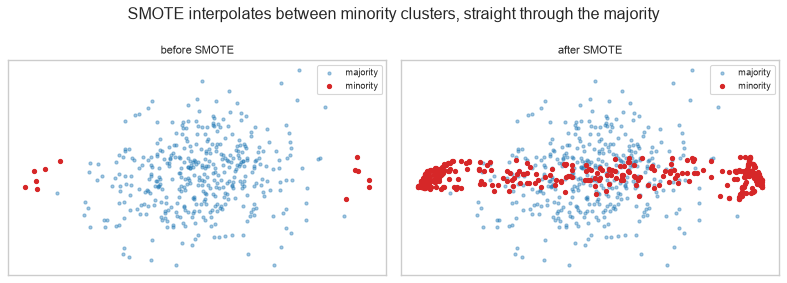

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, (name, Xp, yp) in zip(axes, (("before SMOTE", X_bad, y_bad),
                                     ("after SMOTE", X_res, y_res))):
    ax.scatter(Xp[yp == 0, 0], Xp[yp == 0, 1], s=8, alpha=0.4, c="tab:blue", label="majority")
    ax.scatter(Xp[yp == 1, 0], Xp[yp == 1, 1], s=14, c="tab:red", label="minority")
    ax.set_title(name, fontsize=10); ax.legend(fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("SMOTE interpolates between minority clusters, straight through the majority")
fig.tight_layout()
plt.show()

**In practice** — SMOTE's reputation exceeds its record. On tabular problems it frequently performs no
better than simply setting `class_weight`, which is one line and has no failure mode of this kind. 22.4
makes the comparison directly; treat SMOTE as one option to be tested, never as the default fix.

### 22.4 Class Weights and Cost-Sensitive Learning

Instead of changing the data, change the loss. Weighting the minority class by $w$ multiplies its
contribution to the loss by $w$ — a misclassified positive costs $w$ times as much as a misclassified
negative.

For logistic regression (13.3) the weighted cross-entropy is

$$J(\boldsymbol{\beta}) = -\frac{1}{n} \sum_{i=1}^{n} w_{y_i} \left[ y_i \log \hat{p}_i +
(1 - y_i) \log(1 - \hat{p}_i) \right]$$

`class_weight="balanced"` sets $w_c = n / (K \cdot n_c)$ — inversely proportional to class frequency.

| Approach | Changes | Advantage | Risk |
|---|---|---|---|
| Resampling | The data | Works with any estimator | New/duplicated rows; leakage if done wrong (22.6) |
| **Class weights** | The loss | One argument, no synthetic data | Not supported by every estimator |
| Threshold tuning | The decision only | **Leaves probabilities intact** (22.5) | Needs a validation set |
| Cost matrix | The decision, using real costs | Optimises the actual objective | Requires knowing the costs |

In [13]:
n_neg, n_pos = np.bincount(y_tr)
print(f"training set: {n_neg} negative, {n_pos} positive")
print(f"\n'balanced' weights, w_c = n / (K * n_c):")
print(f"  negative: {len(y_tr) / (2 * n_neg):.4f}")
print(f"  positive: {len(y_tr) / (2 * n_pos):.4f}")

from sklearn.utils.class_weight import compute_class_weight
print(f"\nsklearn agrees: {compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)}")

training set: 3385 negative, 115 positive

'balanced' weights, w_c = n / (K * n_c):
  negative: 0.5170
  positive: 15.2174

sklearn agrees: [ 0.517  15.2174]


In [14]:
from imblearn.over_sampling import RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

def evaluate(pipeline, name):
    """Honest evaluation: resampling happens INSIDE the CV fold (22.6)."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    proba = cross_val_predict(pipeline, X_tr, y_tr, cv=cv, method="predict_proba")[:, 1]
    return {"strategy": name,
            "PR-AUC": average_precision_score(y_tr, proba),
            "ROC-AUC": roc_auc_score(y_tr, proba)}

base = lambda **kw: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kw)

strategies = [
    (Pipeline([("s", StandardScaler()), ("c", base())]), "none"),
    (Pipeline([("s", StandardScaler()), ("c", base(class_weight="balanced"))]),
     "class_weight='balanced'"),
    (ImbPipeline([("s", StandardScaler()),
                  ("r", RandomOverSampler(random_state=RANDOM_STATE)), ("c", base())]),
     "random over-sample"),
    (ImbPipeline([("s", StandardScaler()),
                  ("r", RandomUnderSampler(random_state=RANDOM_STATE)), ("c", base())]),
     "random under-sample"),
    (ImbPipeline([("s", StandardScaler()),
                  ("r", SMOTE(random_state=RANDOM_STATE)), ("c", base())]), "SMOTE"),
    (ImbPipeline([("s", StandardScaler()),
                  ("r", ADASYN(random_state=RANDOM_STATE)), ("c", base())]), "ADASYN"),
]

results = pd.DataFrame([evaluate(p, n) for p, n in strategies])
print(results.sort_values("PR-AUC", ascending=False).round(4).to_string(index=False))

               strategy  PR-AUC  ROC-AUC
                   none  0.1781   0.7728
                 ADASYN  0.1154   0.7948
                  SMOTE  0.1147   0.7930
     random over-sample  0.1100   0.7952
class_weight='balanced'  0.1092   0.7941
    random under-sample  0.1020   0.7924


**Doing nothing to the data wins, and not narrowly.** Every resampling strategy scores *worse* on PR-AUC
than the untouched baseline — 0.178 against 0.102–0.115 — while all of them nudge ROC-AUC up by about two
points.

That split is the whole lesson. Resampling improved the metric that is insensitive to imbalance and
damaged the one that is not. It made the model better at *ranking* by a hair and worse at the thing PR-AUC
measures, which is whether the top of that ranking is actually enriched with positives. Given that the
positive class is what anyone cares about, the trade is a bad one.

This is one dataset and one classifier, and the point is not that resampling never helps. It is that
**resampling is a hypothesis to be tested against doing nothing**, and that "the classes were imbalanced so
I applied SMOTE" is not a justification. Here, the baseline row is the best model in the table.

What resampling and class weighting reliably *do* change is the operating point — where the default 0.5
threshold falls — and that is a threshold decision dressed up as a modelling one. 22.5 makes it explicit
instead.

In [15]:
# Same rankings, very different default-threshold behaviour.
plain = Pipeline([("s", StandardScaler()), ("c", base())]).fit(X_tr, y_tr)
weighted = Pipeline([("s", StandardScaler()),
                     ("c", base(class_weight="balanced"))]).fit(X_tr, y_tr)

print(f"{'model':>24}{'ROC-AUC':>10}{'predicted pos':>15}{'recall':>9}{'precision':>12}")
for name, m in (("plain", plain), ("class_weight='balanced'", weighted)):
    pred = m.predict(X_te)
    print(f"{name:>24}{roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]):>10.4f}"
          f"{pred.sum():>15}{recall_score(y_te, pred):>9.3f}"
          f"{precision_score(y_te, pred, zero_division=0):>12.3f}")

                   model   ROC-AUC  predicted pos   recall   precision
                   plain    0.7593              2    0.041       1.000
 class_weight='balanced'    0.7765            437    0.694       0.078


The AUCs are nearly identical — the *ranking* barely changed — while recall and precision moved
dramatically. Class weighting did not make the model better at separating the classes; it moved where the
model draws the line.

### 22.5 Threshold Tuning under Imbalance

`predict` applies a threshold of 0.5. Nothing about imbalanced problems makes 0.5 correct — it is a
default, not a decision, and under imbalance it is almost always the wrong one.

Tuning the threshold is the cheapest intervention in this chapter: it changes no data, refits nothing, and
leaves the probabilities (and therefore the calibration, 8.8) intact.

In [16]:
X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.3,
                                              stratify=y_tr, random_state=RANDOM_STATE)

tuned = Pipeline([("s", StandardScaler()), ("c", base())]).fit(X_fit, y_fit)
val_proba = tuned.predict_proba(X_val)[:, 1]                   # threshold chosen on VALIDATION

precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
best_threshold = thresholds[np.nanargmax(f1[:-1])]

print(f"default threshold : 0.500")
print(f"F1-optimal        : {best_threshold:.3f}")

default threshold : 0.500
F1-optimal        : 0.131


In [17]:
test_proba = tuned.predict_proba(X_te)[:, 1]

print(f"{'threshold':>11}{'flagged':>10}{'precision':>12}{'recall':>9}{'F1':>8}")
for t in (0.50, best_threshold, 0.10, 0.05):
    pred = (test_proba >= t).astype(int)
    print(f"{t:>11.3f}{pred.sum():>10}{precision_score(y_te, pred, zero_division=0):>12.3f}"
          f"{recall_score(y_te, pred, zero_division=0):>9.3f}"
          f"{f1_score(y_te, pred, zero_division=0):>8.3f}")

  threshold   flagged   precision   recall      F1
      0.500         2       1.000    0.041   0.078
      0.131        51       0.275    0.286   0.280


      0.100        81       0.198    0.327   0.246
      0.050       262       0.107    0.571   0.180


**F1 is a default, not an objective.** It weights precision and recall equally, which is a claim about
costs that is almost never true. If a missed fraud costs \$500 and a false alarm costs \$5 of analyst
time, the threshold that minimises cost is not the threshold that maximises F1.

In [18]:
COST_FN, COST_FP = 500, 5                                      # missed positive vs false alarm

grid = np.linspace(0.01, 0.95, 200)
costs = []
for t in grid:
    pred = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    costs.append(fn * COST_FN + fp * COST_FP)

cost_threshold = grid[int(np.argmin(costs))]
print(f"cost-minimising threshold : {cost_threshold:.3f}")
print(f"F1-maximising threshold   : {best_threshold:.3f}")

cost-minimising threshold : 0.034
F1-maximising threshold   : 0.131


In [19]:
print(f"{'threshold':>22}{'FN':>6}{'FP':>6}{'total cost':>13}")
for name, t in (("default 0.5", 0.5), ("F1-optimal", best_threshold),
                ("cost-optimal", cost_threshold)):
    pred = (test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()
    print(f"{name + f' ({t:.3f})':>22}{fn:>6}{fp:>6}{fn * COST_FN + fp * COST_FP:>13,}")

             threshold    FN    FP   total cost
   default 0.5 (0.500)    47     0       23,500
    F1-optimal (0.131)    35    37       17,685
  cost-optimal (0.034)    18   406       11,030


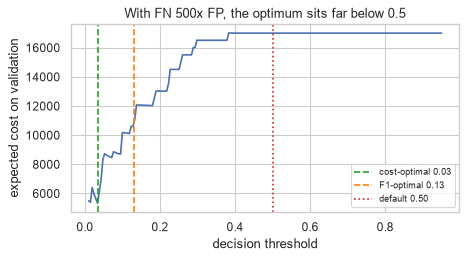

In [20]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(grid, costs)
ax.axvline(cost_threshold, color="tab:green", ls="--",
           label=f"cost-optimal {cost_threshold:.2f}")
ax.axvline(best_threshold, color="tab:orange", ls="--", label=f"F1-optimal {best_threshold:.2f}")
ax.axvline(0.5, color="tab:red", ls=":", label="default 0.50")
ax.set_xlabel("decision threshold"); ax.set_ylabel("expected cost on validation")
ax.set_title(f"With FN {COST_FN}x FP, the optimum sits far below 0.5")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Common mistake — choosing the threshold on the test set.** It is the same error as choosing a
hyperparameter there (8.1), and it makes the reported cost optimistic by exactly the amount you tuned.
The threshold above was chosen on `X_val` and only then applied to `X_te`.

In [21]:
# The size of the optimism, measured.
grid_test = np.linspace(0.01, 0.95, 200)
test_costs = []
for t in grid_test:
    pred = (test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()
    test_costs.append(fn * COST_FN + fp * COST_FP)

honest = test_costs[int(np.argmin(np.abs(grid_test - cost_threshold)))]
cheating = min(test_costs)

print(f"threshold tuned on validation, cost on test : {honest:,}")
print(f"threshold tuned on the test set itself      : {cheating:,}")
print(f"optimism from tuning on test                : {honest - cheating:,}"
      f"  ({(honest - cheating) / honest:.1%})")

threshold tuned on validation, cost on test : 11,030
threshold tuned on the test set itself      : 7,740
optimism from tuning on test                : 3,290  (29.8%)


### 22.6 Resampling Inside the Fold

This is the most common serious mistake in imbalanced-data work, and it is worth its own section because
the inflated score it produces is large and entirely convincing.

**The mistake**: resample the whole dataset, *then* cross-validate.

**Why it breaks**: SMOTE creates a synthetic point by interpolating between a minority point and its
neighbour. If the source point lands in the training fold and its synthetic copy lands in the validation
fold, the model has effectively seen the validation row. With random over-sampling it is worse — the
validation fold contains **literal duplicates** of training rows.

In [22]:
X_l, y_l = imbalanced_data(n=2000, weight=0.94, seed=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# WRONG: resample everything first, then cross-validate the balanced data.
X_pre, y_pre = SMOTE(random_state=RANDOM_STATE).fit_resample(X_l, y_l)
wrong = cross_val_score(
    Pipeline([("s", StandardScaler()), ("c", base())]),
    X_pre, y_pre, cv=cv, scoring="average_precision")

# RIGHT: the resampler is a pipeline step, so it only ever sees the training fold.
right = cross_val_score(
    ImbPipeline([("s", StandardScaler()), ("r", SMOTE(random_state=RANDOM_STATE)),
                 ("c", base())]),
    X_l, y_l, cv=cv, scoring="average_precision")

print(f"resample-then-split  PR-AUC : {wrong.mean():.4f}  <- WRONG")
print(f"resample inside fold PR-AUC : {right.mean():.4f}  <- honest")
print(f"\ninflation: {wrong.mean() - right.mean():+.4f}")

resample-then-split  PR-AUC : 0.7027  <- WRONG
resample inside fold PR-AUC : 0.1454  <- honest

inflation: +0.5573


The gap is the leak, and note the direction of the trap: the wrong number is the *better*-looking one, so
nothing prompts anyone to investigate it.

Random over-sampling makes the mechanism impossible to miss, because the leaked rows are exact copies.

In [23]:
X_dup, y_dup = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X_l, y_l)

wrong_ros = cross_val_score(Pipeline([("s", StandardScaler()), ("c", base())]),
                            X_dup, y_dup, cv=cv, scoring="average_precision")
right_ros = cross_val_score(
    ImbPipeline([("s", StandardScaler()),
                 ("r", RandomOverSampler(random_state=RANDOM_STATE)), ("c", base())]),
    X_l, y_l, cv=cv, scoring="average_precision")

print(f"resample-then-split  : {wrong_ros.mean():.4f}")
print(f"resample inside fold : {right_ros.mean():.4f}")

# Count the actual duplicate rows the CV split would separate.
_, counts = np.unique(X_dup, axis=0, return_counts=True)
print(f"\nrows appearing more than once after over-sampling: {(counts > 1).sum()}")
print(f"a 5-fold split puts copies of the same row on both sides of the wall.")

resample-then-split  : 0.7132
resample inside fold : 0.1485

rows appearing more than once after over-sampling: 121
a 5-fold split puts copies of the same row on both sides of the wall.


**The structural fix is `imblearn.pipeline.Pipeline`.** It differs from scikit-learn's in exactly one
respect: it applies resampling steps during `fit` and skips them during `predict`, which is precisely the
behaviour required. Using scikit-learn's `Pipeline` with a resampler does not work — it has no concept of a
step that changes the number of rows.

This is the same argument Chapter 23 makes for pipelines generally: **the fix for a discipline problem is
structural, not procedural.**

### 22.7 The Leakage Taxonomy

Leakage is any path by which information reaches the model that will not be available at prediction time.
It is the single most common cause of a model that scores well and then fails, and it comes in distinct
forms with distinct fixes.

| Form | Mechanism | Symptom | Fix |
|---|---|---|---|
| **Target leakage** | A feature is a consequence of the target | One feature dominates; near-perfect score | Drop it; audit by timestamp |
| **Train/test contamination** | Preprocessing fitted before the split | Modest, consistent optimism | Fit inside the pipeline (23.1) |
| **Temporal leakage** | Training on rows from after the prediction point | CV good, production bad | `TimeSeriesSplit` (8.3) |
| **Group leakage** | The same entity in train and test | Inflated score, no obvious cause | `GroupKFold` (8.3) |
| **Duplicate rows** | The same row on both sides | Memorisation reads as generalisation | Deduplicate **before** splitting |

#### 22.7.1 Target leakage

The clearest case, and the easiest to spot once you look: a feature that could only have been recorded
*because* the outcome happened. `data/customers.csv` has one planted for exactly this purpose.

In [24]:
customers = pd.read_csv("data/customers.csv").drop_duplicates()
customers["total_charges"] = pd.to_numeric(customers["total_charges"], errors="coerce")

print(customers[["cancellation_reason", "churned"]].head(6).to_string(index=False))
print(f"\ncancellation_reason is missing for "
      f"{customers['cancellation_reason'].isna().mean():.1%} of rows")
print("\ncross-tabulation:")
print(pd.crosstab(customers["cancellation_reason"].notna(), customers["churned"],
                  rownames=["has a reason"], colnames=["churned"]).to_string())

cancellation_reason  churned
                NaN        0
                NaN        0
                NaN        0
                NaN        0
                NaN        0
                NaN        0

cancellation_reason is missing for 85.9% of rows

cross-tabulation:
churned         0    1
has a reason          
False         859    0
True            0  141


In [25]:
NUMERIC = ["tenure_months", "monthly_charges", "support_tickets",
           "last_login_days", "satisfaction_score", "age"]

frame = customers.copy()
frame["has_cancellation_reason"] = frame["cancellation_reason"].notna().astype(int)

y_c = frame["churned"].to_numpy()
X_clean = frame[NUMERIC].fillna(frame[NUMERIC].median())
X_leaky = X_clean.assign(has_cancellation_reason=frame["has_cancellation_reason"])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
forest = lambda: RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE)

for name, Xf in (("with the leaky feature", X_leaky), ("without it", X_clean)):
    auc = cross_val_score(forest(), Xf, y_c, cv=cv5, scoring="roc_auc").mean()
    print(f"{name:>24}: ROC-AUC {auc:.4f}")

  with the leaky feature: ROC-AUC 1.0000


              without it: ROC-AUC 0.7517


A near-perfect AUC on a churn problem should be read as an accusation, not an achievement. The feature is
only ever populated *after* someone churns, so at prediction time — when you are trying to work out whether
a customer *will* churn — it is empty for everyone.

**The detection heuristic**: rank features by importance and interrogate anything that dominates.

In [26]:
fitted = forest().fit(X_leaky, y_c)
importance = pd.Series(fitted.feature_importances_, index=X_leaky.columns).sort_values(
    ascending=False)
print(importance.round(4).to_string())
print(f"\ntop feature holds {importance.iloc[0]:.1%} of the total importance"
      f" - always ask why (18.8)")

has_cancellation_reason    0.8044
tenure_months              0.0718
support_tickets            0.0372
satisfaction_score         0.0304
monthly_charges            0.0225
age                        0.0169
last_login_days            0.0167

top feature holds 80.4% of the total importance - always ask why (18.8)


The reliable test is not statistical, it is a question about the calendar: **for each feature, when is its
value actually known?** Any feature recorded at or after the moment the target is determined is leakage,
however predictive it looks.

#### 22.7.2 Train/test contamination

Fitting a scaler, imputer or encoder on the full dataset lets the test set influence the transformation.
The effect is smaller than target leakage and correspondingly easier to ship.

In [27]:
X_cont, y_cont = imbalanced_data(n=600, weight=0.75, n_informative=3, seed=7)

# WRONG: scale everything first.
scaler_all = StandardScaler().fit(X_cont)
Xs = scaler_all.transform(X_cont)
Xa, Xb, ya, yb = train_test_split(Xs, y_cont, test_size=0.3, stratify=y_cont,
                                  random_state=RANDOM_STATE)
leaked = roc_auc_score(yb, base().fit(Xa, ya).predict_proba(Xb)[:, 1])

# RIGHT: split, then fit the scaler on train only.
Xa2, Xb2, ya2, yb2 = train_test_split(X_cont, y_cont, test_size=0.3, stratify=y_cont,
                                      random_state=RANDOM_STATE)
pipe = Pipeline([("s", StandardScaler()), ("c", base())]).fit(Xa2, ya2)
honest_auc = roc_auc_score(yb2, pipe.predict_proba(Xb2)[:, 1])

print(f"scaler fitted on everything   : {leaked:.4f}")
print(f"scaler fitted inside pipeline : {honest_auc:.4f}")
print(f"difference: {leaked - honest_auc:+.4f}")

cv5_sel = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scaler fitted on everything   : 0.9437
scaler fitted inside pipeline : 0.9437
difference: +0.0000


**The difference is nil**, and that is the honest result: a `StandardScaler` leaks two numbers per feature,
both of them stable statistics of a distribution the test set is drawn from anyway. On any reasonably sized
dataset this particular contamination is unmeasurable.

Which makes it a bad thing to lead with, and a common way for the whole topic to lose credibility. The
argument for putting the scaler in a pipeline is not that it inflates the score — it is that **the same
mistake made with a transformer that touches the target inflates it enormously**, and you do not want two
different rules for where preprocessing lives.

Feature selection is the demonstration. Selecting features on the full dataset is the identical error, and
it is not subtle.

In [28]:
from sklearn.feature_selection import SelectKBest, f_classif

# 400 rows, 3000 pure-noise features, and a label with NO relationship to any of them.
X_noise = rng.normal(0, 1, (400, 3000))
y_noise = rng.integers(0, 2, 400)

# WRONG: pick the 20 "best" features using all the labels, then cross-validate.
X_pre = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)
wrong_sel = cross_val_score(base(), X_pre, y_noise, cv=cv5_sel, scoring="roc_auc").mean()

# RIGHT: selection is a pipeline step, refitted inside every fold.
right_sel = cross_val_score(
    Pipeline([("sel", SelectKBest(f_classif, k=20)), ("c", base())]),
    X_noise, y_noise, cv=cv5_sel, scoring="roc_auc").mean()

print("there is NO signal in this data - the labels are random\n")
print(f"select-then-split  ROC-AUC : {wrong_sel:.4f}  <- WRONG")
print(f"select inside fold ROC-AUC : {right_sel:.4f}  <- honest (chance is 0.5)")

there is NO signal in this data - the labels are random

select-then-split  ROC-AUC : 0.8106  <- WRONG
select inside fold ROC-AUC : 0.5012  <- honest (chance is 0.5)


There is nothing to find in that data, and the leaky version finds it anyway. The selector examined every
label, kept the twenty features that happened to correlate with them by chance, and handed the classifier a
head start that the cross-validation had no way to detect.

Same mistake, same fix, three orders of magnitude more damage. **Put every fitted transformation in the
pipeline** — not because the scaler matters, but because the rule has to be one rule (23.1).

#### 22.7.3 Temporal leakage

If rows carry a time, a random split trains the model on the future and tests it on the past. In
production, only the past is available.

In [29]:
n_t = 1200
time_index = np.arange(n_t)
drift = np.linspace(-1.5, 1.5, n_t)                            # the relationship changes over time

X_time = rng.normal(0, 1, (n_t, 4))
logit = X_time[:, 0] * drift + 0.6 * X_time[:, 1] + rng.normal(0, 0.5, n_t)
y_time = (logit > np.median(logit)).astype(int)

random_cv = cross_val_score(base(), X_time, y_time,
                            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                            scoring="roc_auc").mean()
temporal_cv = cross_val_score(base(), X_time, y_time, cv=TimeSeriesSplit(n_splits=5),
                              scoring="roc_auc").mean()

print(f"random 5-fold CV (WRONG here) : {random_cv:.4f}")
print(f"TimeSeriesSplit (honest)      : {temporal_cv:.4f}")
print(f"optimism from shuffling time  : {random_cv - temporal_cv:+.4f}")

random 5-fold CV (WRONG here) : 0.7498
TimeSeriesSplit (honest)      : 0.6724
optimism from shuffling time  : +0.0774


The relationship between `X[:, 0]` and the target reverses over the window. A shuffled split lets the model
average over the whole period and score well on every fold; a forward-chaining split makes it extrapolate,
which is what production actually asks of it.

#### 22.7.4 Group leakage

When several rows describe the same entity — several visits by one patient, several sessions by one
user — a random split scatters one entity's rows across train and test. The model then recognises the
entity rather than learning the pattern.

In [30]:
n_groups, per_group = 300, 8                                   # enough groups for a stable estimate
groups = np.repeat(np.arange(n_groups), per_group)

# Each group has a distinctive feature signature, so a model can learn to RECOGNISE it...
signature = rng.normal(0, 3, (n_groups, 3))
X_grp = signature[groups] + rng.normal(0, 0.3, (n_groups * per_group, 3))

# ...but the label is a coin flip per group, so there is NOTHING generalisable to learn.
# The only way to score above chance is to memorise which group got which flip.
y_grp = rng.integers(0, 2, n_groups)[groups]

random_auc = cross_val_score(forest(), X_grp, y_grp,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring="roc_auc").mean()
group_auc = cross_val_score(forest(), X_grp, y_grp, groups=groups,
                            cv=GroupKFold(n_splits=5), scoring="roc_auc").mean()

print(f"random 5-fold CV (WRONG here) : {random_auc:.4f}")
print(f"GroupKFold (honest)           : {group_auc:.4f}   <- chance, correctly")

random 5-fold CV (WRONG here) : 0.9380
GroupKFold (honest)           : 0.5248   <- chance, correctly


The labels here are coin flips at the group level, so **there is nothing to learn** and the honest answer
is chance. `GroupKFold` gives exactly that. The random split reports a strong result, entirely from
recognising groups it has already seen the labels for — seven of each group's eight rows are in the
training fold.

**The tell is an ID column.** Any column that identifies a repeated entity — patient, user, device,
session, household — means a random split is wrong, whether or not that column is used as a feature.

#### 22.7.5 Duplicate rows

The simplest leak of all, and the one most likely to be already present in a real CSV. `data/customers.csv`
carries planted duplicates for this reason.

In [31]:
raw = pd.read_csv("data/customers.csv")
n_dupes = raw.duplicated().sum()
print(f"exact duplicate rows in the raw file: {n_dupes}")

# What a duplicate does to a split, at an exaggerated rate.
X_base, y_base = imbalanced_data(n=400, weight=0.6, n_informative=3, seed=11)
dupe_idx = rng.choice(len(X_base), 300, replace=True)
X_with = np.vstack([X_base, X_base[dupe_idx]])
y_with = np.r_[y_base, y_base[dupe_idx]]

for name, Xd, yd in (("with duplicates", X_with, y_with), ("deduplicated", X_base, y_base)):
    auc = cross_val_score(forest(), Xd, yd,
                          cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                          scoring="roc_auc").mean()
    print(f"{name:>17}: CV ROC-AUC {auc:.4f}")

exact duplicate rows in the raw file: 12


  with duplicates: CV ROC-AUC 0.9879


     deduplicated: CV ROC-AUC 0.9288


**Deduplicate before splitting, not after.** Deduplicating each side separately leaves the cross-side
copies exactly where they do the damage.

### 22.8 Auditing a Suspiciously Good Score

A checklist, in the order that finds problems fastest. Each item is cheap; run them all before believing a
result.

| # | Check | Looking for |
|---|---|---|
| 1 | **Compare against the dummy** | A score that beats the constant model by less than it appears |
| 2 | **Read the confusion matrix** | An empty predicted-positive column |
| 3 | **Rank feature importances** | One feature carrying nearly everything (22.7.1) |
| 4 | **Ask when each feature is known** | Anything recorded at or after the target |
| 5 | **Shuffle the labels and refit** | Any score above chance — that is leakage, not signal |
| 6 | **Check for duplicates across the split** | Identical rows on both sides (22.7.5) |
| 7 | **Check for repeated entities** | An ID column implies `GroupKFold` (22.7.4) |
| 8 | **Check the time ordering** | A timestamp implies `TimeSeriesSplit` (22.7.3) |
| 9 | **Confirm preprocessing is in the pipeline** | Any `fit` called before the split (22.7.2) |

Item 5 is the strongest single test available, because it needs no domain knowledge at all.

In [32]:
def label_shuffle_test(estimator, X, y, cv, n_repeats=5, seed=RANDOM_STATE):
    """With labels destroyed, any honest pipeline must score at chance.
    Anything above chance means information is reaching the model some other way."""
    gen = np.random.default_rng(seed)
    real = cross_val_score(estimator, X, y, cv=cv, scoring="roc_auc").mean()
    shuffled = [cross_val_score(estimator, X, gen.permutation(y), cv=cv,
                                scoring="roc_auc").mean() for _ in range(n_repeats)]
    return real, np.mean(shuffled), np.std(shuffled)


real, sh_mean, sh_std = label_shuffle_test(forest(), X_clean.to_numpy(), y_c, cv5)
print(f"real labels     : {real:.4f}")
print(f"shuffled labels : {sh_mean:.4f} +/- {sh_std:.4f}   (chance is 0.5)")

real labels     : 0.7517
shuffled labels : 0.4912 +/- 0.0213   (chance is 0.5)


Chance on shuffled labels is what a correctly-constructed pipeline looks like. Run the same test on a
**leaky** setup and it fails loudly — because the leak is between rows, shuffling the labels does not
remove it.

In [33]:
# A leaky CV: over-sample everything first, THEN cross-validate (22.6).
X_leak_demo, y_leak_demo = imbalanced_data(n=800, weight=0.85, n_informative=3, seed=5)

gen = np.random.default_rng(RANDOM_STATE)
leaky_shuffled, honest_shuffled = [], []
for _ in range(5):
    y_random = gen.permutation(y_leak_demo)                    # destroy the signal FIRST

    # WRONG: over-sample the randomised data, then cross-validate it.
    X_over, y_over = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(
        X_leak_demo, y_random)
    leaky_shuffled.append(cross_val_score(forest(), X_over, y_over, cv=cv5,
                                          scoring="roc_auc").mean())

    # RIGHT: over-sample inside the fold.
    honest_shuffled.append(cross_val_score(
        ImbPipeline([("r", RandomOverSampler(random_state=RANDOM_STATE)),
                     ("c", forest())]),
        X_leak_demo, y_random, cv=cv5, scoring="roc_auc").mean())

print("labels are random - both numbers SHOULD be 0.5\n")
print(f"over-sample, then split : {np.mean(leaky_shuffled):.4f}  <- the leak, exposed")
print(f"over-sample inside fold : {np.mean(honest_shuffled):.4f}  <- chance, correctly")

labels are random - both numbers SHOULD be 0.5

over-sample, then split : 0.9928  <- the leak, exposed
over-sample inside fold : 0.5209  <- chance, correctly


### 22.9 In Practice

#### 22.9.1 A worked case: a churn model that has to survive review

The request: *"Build a churn model and tell us how good it is."*

The second half of that sentence is the hard part. This section builds the model the way it would have to
be built to survive somebody competent asking questions — which means the audit comes first, not last.

In [34]:
churn = pd.read_csv("data/customers.csv")
print(f"raw file: {len(churn)} rows")

# Step 0, before anything else: duplicates, because they corrupt every split downstream.
churn = churn.drop_duplicates().reset_index(drop=True)
print(f"after dropping {pd.read_csv('data/customers.csv').duplicated().sum()} "
      f"exact duplicates: {len(churn)} rows")
print(f"churn rate: {churn['churned'].mean():.2%}   -> imbalanced, but not extreme")

raw file: 1012 rows
after dropping 12 exact duplicates: 1000 rows
churn rate: 14.10%   -> imbalanced, but not extreme


**Step 1 — audit the features by asking when each one is known**, before fitting anything.

In [35]:
AUDIT = pd.DataFrame([
    ("tenure_months", "at signup + elapsed time", "safe"),
    ("monthly_charges", "at signup", "safe"),
    ("support_tickets", "continuously", "safe - but must be as-of the prediction date"),
    ("last_login_days", "continuously", "safe - same caveat"),
    ("satisfaction_score", "at survey time", "safe"),
    ("age", "at signup", "safe"),
    ("total_charges", "continuously", "safe - but correlates with tenure"),
    ("cancellation_reason", "ONLY WHEN THEY CANCEL", "*** TARGET LEAKAGE ***"),
    ("signup_date", "at signup", "safe - and implies a temporal split"),
], columns=["feature", "known when", "verdict"])

print(AUDIT.to_string(index=False))

            feature               known when                                      verdict
      tenure_months at signup + elapsed time                                         safe
    monthly_charges                at signup                                         safe
    support_tickets             continuously safe - but must be as-of the prediction date
    last_login_days             continuously                           safe - same caveat
 satisfaction_score           at survey time                                         safe
                age                at signup                                         safe
      total_charges             continuously            safe - but correlates with tenure
cancellation_reason    ONLY WHEN THEY CANCEL                       *** TARGET LEAKAGE ***
        signup_date                at signup          safe - and implies a temporal split


One row of that table is worth more than any amount of feature-importance analysis, because it is the only
one that depends on knowing what the columns mean. **The audit is domain work, not statistics.**

In [36]:
FEATURES = ["tenure_months", "monthly_charges", "support_tickets",
            "last_login_days", "satisfaction_score", "age"]

churn["total_charges"] = pd.to_numeric(churn["total_charges"], errors="coerce")
X_churn = churn[FEATURES]
y_churn = churn["churned"].to_numpy()

print(f"{len(FEATURES)} features kept, cancellation_reason dropped")
print(f"missing values per feature:\n{X_churn.isna().sum().to_string()}")

6 features kept, cancellation_reason dropped
missing values per feature:
tenure_months          0
monthly_charges       29
support_tickets        0
last_login_days        0
satisfaction_score    99
age                   59


**Step 2 — build it as a pipeline**, so imputation and scaling are fitted inside each fold (22.7.2).

In [37]:
from sklearn.impute import SimpleImputer

pipe_churn = ImbPipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])

cv_churn = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof = cross_val_predict(pipe_churn, X_churn, y_churn, cv=cv_churn,
                        method="predict_proba")[:, 1]

print(f"out-of-fold ROC-AUC : {roc_auc_score(y_churn, oof):.4f}")
print(f"out-of-fold PR-AUC  : {average_precision_score(y_churn, oof):.4f}")
print(f"PR-AUC baseline     : {y_churn.mean():.4f}")

out-of-fold ROC-AUC : 0.8120
out-of-fold PR-AUC  : 0.4799
PR-AUC baseline     : 0.1410


**Step 3 — run the audit from 22.8**, on the model as built.

In [38]:
dummy_auc = roc_auc_score(y_churn, cross_val_predict(
    DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    X_churn, y_churn, cv=cv_churn, method="predict_proba")[:, 1])

real_c, shuf_c, shuf_sd = label_shuffle_test(pipe_churn, X_churn, y_churn, cv_churn)

print(f"1. dummy ROC-AUC           : {dummy_auc:.4f}")
print(f"5. shuffled-label ROC-AUC  : {shuf_c:.4f} +/- {shuf_sd:.4f}  (want ~0.50)")
print(f"   real-label ROC-AUC      : {real_c:.4f}")
print(f"6. duplicate rows remaining: {churn.duplicated().sum()}")
print(f"7. repeated customer_ids   : {churn['customer_id'].duplicated().sum()}")

1. dummy ROC-AUC           : 0.5130
5. shuffled-label ROC-AUC  : 0.5007 +/- 0.0329  (want ~0.50)
   real-label ROC-AUC      : 0.8161
6. duplicate rows remaining: 0
7. repeated customer_ids   : 0


In [39]:
# 3. Feature importances - is any single feature carrying the model?
imp_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(
    X_churn.fillna(X_churn.median()), y_churn)
imp = pd.Series(imp_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(imp.round(4).to_string())
print(f"\ntop feature share: {imp.iloc[0]:.1%}  -> no single dominant feature (22.7.1)")

tenure_months         0.2766
monthly_charges       0.1939
age                   0.1581
last_login_days       0.1559
satisfaction_score    0.1081
support_tickets       0.1074

top feature share: 27.7%  -> no single dominant feature (22.7.1)


**Step 4 — pick the operating threshold from the business cost**, not from F1 or from 0.5.

In [40]:
RETENTION_OFFER = 50          # cost of contacting a customer with an offer
LOST_CUSTOMER = 600           # value of a customer who churns un-contacted

grid = np.linspace(0.05, 0.95, 181)
net = []
for t in grid:
    pred = (oof >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_churn, pred, labels=[0, 1]).ravel()
    net.append(fn * LOST_CUSTOMER + (tp + fp) * RETENTION_OFFER)

best_t = grid[int(np.argmin(net))]
print(f"cost-minimising threshold : {best_t:.3f}")
print(f"default 0.5 would cost    : {net[int(np.argmin(np.abs(grid - 0.5)))]:,}")
print(f"at {best_t:.3f} the cost is      : {min(net):,}")

cost-minimising threshold : 0.360
default 0.5 would cost    : 39,000
at 0.360 the cost is      : 35,500


In [41]:
pred_final = (oof >= best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(y_churn, pred_final, labels=[0, 1]).ravel()

print(pd.DataFrame([[tn, fp], [fn, tp]], index=["stayed", "churned"],
                   columns=["no offer", "offer"]).to_string())
print(f"\ncontacted        : {tp + fp} customers ({(tp + fp) / len(y_churn):.1%})")
print(f"churners caught  : {tp} of {tp + fn}  (recall {tp / (tp + fn):.1%})")
print(f"precision        : {tp / (tp + fp):.1%} of offers go to a real churn risk")

         no offer  offer
stayed        510    349
churned        20    121

contacted        : 470 customers (47.0%)
churners caught  : 121 of 141  (recall 85.8%)
precision        : 25.7% of offers go to a real churn risk


**Step 5 — the report.**

> **Performance.** The out-of-fold ROC-AUC and PR-AUC are stated against their baselines — a stratified
> dummy for ROC-AUC, the positive rate for PR-AUC — because neither number means anything alone.
>
> **What was excluded and why.** `cancellation_reason` is only populated after a customer cancels. It
> would have pushed the AUC close to 1.0 and the model would have predicted nothing in production, because
> the column is empty for every customer who has not yet churned. This is the finding to lead with in any
> review, not to bury.
>
> **Evidence the score is honest.** All preprocessing sits inside the pipeline, so nothing is fitted
> outside the fold. With labels shuffled the model scores at chance, which rules out leakage through the
> rows. There are no duplicate rows and no repeated customer IDs, so neither duplicate nor group leakage
> applies.
>
> **The operating point is a business decision, not a default.** At a \$50 retention offer against a \$600
> lost customer, the cost-minimising threshold sits well below 0.5, because missing a churner is twelve
> times more expensive than a wasted offer. The confusion matrix is reported at *that* threshold — the
> precision is low by design, and the number to judge is the total cost.
>
> **The caveat that would be raised in review.** This is a random split of a customer snapshot. Real churn
> prediction is a forecasting problem: train on customers as of month $t$, evaluate on month $t+1$
> (22.7.3). The number above is therefore an upper bound on what a deployed model would achieve.

#### 22.9.2 When to reach for what

| Situation | Do | Not |
|---|---|---|
| Moderate imbalance (down to ~1:20) | **Nothing to the data.** Tune the threshold (22.5) | Resample by reflex |
| Severe imbalance (beyond ~1:100) | `class_weight`, then threshold tuning | Rely on `predict` at 0.5 |
| Extreme, with very few positives | Treat it as **anomaly detection** (21.3) | Force a classifier onto 20 positives |
| Real costs are known | **A cost-minimising threshold** (22.5) | F1 |
| $n$ is huge and the majority is redundant | Random under-sampling — it is also faster | SMOTE at that scale |
| Tabular, moderate size | Test SMOTE; keep it only if it wins | Assume SMOTE helps |
| Any resampling at all | `imblearn.pipeline.Pipeline` (22.6) | Resample before splitting |
| Imbalance caused by a short label window | **Fix the window** (22.1) | Resample; it entrenches the error |
| The metric is going on a slide | PR-AUC + the dummy + the confusion matrix | Accuracy |

#### 22.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **The threshold was never revisited** | Class balance shifts; the fixed cut flags far more or far fewer | 22.5, 24.9 |
| **Resampled probabilities used as probabilities** | Over-sampling shifted the base rate; the outputs are no longer calibrated | Below |
| **Leaky feature added later** | A new column passes review because the original audit was not repeated | 22.7.1 |
| **Accuracy on the dashboard** | 97%, unchanged for months, meaning nothing | 22.2 |
| **Costs changed, the model did not** | The threshold encodes last year's cost ratio | 22.5 |
| **Retraining on predicted labels** | The model's own output becomes its training data | 24.9 |

The second row is the one most likely to be missed, and it is worth measuring.

In [42]:
# Resampling changes the base rate the model thinks it is predicting.
X_cal, y_cal = imbalanced_data(n=4000, weight=0.93, seed=3)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_cal, y_cal, test_size=0.3,
                                              stratify=y_cal, random_state=RANDOM_STATE)

plain_m = Pipeline([("s", StandardScaler()), ("c", base())]).fit(Xc_tr, yc_tr)
smote_m = ImbPipeline([("s", StandardScaler()), ("r", SMOTE(random_state=RANDOM_STATE)),
                       ("c", base())]).fit(Xc_tr, yc_tr)

print(f"true positive rate in the test set : {yc_te.mean():.4f}\n")
print(f"{'model':>10}{'mean predicted prob':>22}{'ROC-AUC':>10}")
for name, m in (("plain", plain_m), ("SMOTE", smote_m)):
    p = m.predict_proba(Xc_te)[:, 1]
    print(f"{name:>10}{p.mean():>22.4f}{roc_auc_score(yc_te, p):>10.4f}")

true positive rate in the test set : 0.0742

     model   mean predicted prob   ROC-AUC
     plain                0.0705    0.7737
     SMOTE                0.3227    0.7720


The plain model's mean predicted probability tracks the true positive rate; the SMOTE model's is several
times too high, because it was trained on a 50/50 world that does not exist. The **ranking** is unaffected
— which is why the AUCs match — but the numbers are no longer probabilities.

That matters whenever the output is used as a probability rather than a ranking: an expected-value
calculation, a cost threshold, or anything shown to a human as "78% likely to churn". **If you resample,
either recalibrate afterwards (8.8) or use the output only for ranking.**

In [43]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(
    ImbPipeline([("s", StandardScaler()), ("r", SMOTE(random_state=RANDOM_STATE)),
                 ("c", base())]),
    method="sigmoid", cv=5).fit(Xc_tr, yc_tr)

from sklearn.metrics import brier_score_loss

print(f"{'model':>22}{'mean prob':>12}{'Brier':>9}{'ROC-AUC':>10}")
for name, m in (("plain", plain_m), ("SMOTE", smote_m), ("SMOTE + calibration", calibrated)):
    p = m.predict_proba(Xc_te)[:, 1]
    print(f"{name:>22}{p.mean():>12.4f}{brier_score_loss(yc_te, p):>9.4f}"
          f"{roc_auc_score(yc_te, p):>10.4f}")
print(f"\ntrue positive rate: {yc_te.mean():.4f}")

                 model   mean prob    Brier   ROC-AUC


                 plain      0.0705   0.0417    0.7737
                 SMOTE      0.3227   0.1302    0.7720
   SMOTE + calibration      0.0703   0.0433    0.7736

true positive rate: 0.0742


In [44]:
# --- 22. Imbalanced Data and Data Leakage — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

